Mini-project: adoptable dog predictor

Goal: predict whether or not a dog will be adopted quickly (1) or not adopted quickly (0)

Synthetic data 

Features:
- age (years)
- size (0=small,1=medium,2=large)
- energy_level (1–5)
- good_with_kids (0/1)
- trained (0/1)

In [16]:
import numpy as np
import pandas as pd

np.random.seed(42)

m = 200

age = np.random.randint(0, 15, size=m)
size = np.random.choice([0,1,2], size=m)
energy_level = np.random.choice([1,2,3,4,5], size=m)
good_with_kids = np.random.choice([0,1], size=m)
trained = np.random.choice([0,1], size=m)

X = pd.DataFrame({
    "age": age,
    "size": size,
    "energy_level": energy_level,
    "good_with_kids": good_with_kids,
    "trained": trained
})

X.head()

,age,size,energy_level,good_with_kids,trained
0,6,0,4,0,1
1,3,2,1,1,0
2,12,2,4,1,0
3,14,0,5,0,1
4,10,2,5,0,1


Target:
- adopted_fast (0/1)

Let's invent some simple adoption rule: dogs are adopted fast if they are:
- young
- good with kids
- trained

Energy level also helps a bit

We also need to add a bit of noise so the model has to learn patterns

In [28]:
score = (
    (age < 5)*2 +
    good_with_kids*2 +
    trained*2 +
    (energy_level >= 4)*1
)

y = (score >= 3).astype(int)

# add randomness
np.random.seed(42)
noise = np.random.rand(m) < 0.1
y = np.where(noise, 1 - y, y)

data = X.copy()
data["adopted_fast"] = y
data.head()

,age,size,energy_level,good_with_kids,trained,adopted_fast
0,6,0,4,0,1,1
1,3,2,1,1,0,1
2,12,2,4,1,0,1
3,14,0,5,0,1,1
4,10,2,5,0,1,1


Train/Test split for later

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Implement functions for:
- gini impurity
- entropy
- information gain

In [ ]:
def gini_impurity(node):
    if len(node)==0:
        return 0
    p = np.mean(node)
    return 1 - p**2 - (1-p)**2

def entropy(node):
    if len(node)==0:
        return 0
    p = np.mean(node)
    if p==0 or p==1:
        return 0
    return - p * np.log2(p) - (1-p) * np.log2(1-p)

def information_gain(parent, left, right):
    if len(left)==0 or len(right)==0:
        return 0
    w_left = len(left)/len(parent)
    w_right = len(right)/len(parent)
    return entropy(parent) - (w_left * entropy(left) + w_right * entropy(right))

Build a simple tree:

In [43]:
# Find the best split using best information gain
def best_split(X, y):
    best_feature = None
    best_threshold = None
    best_gain = -1
    best_left_mask = None
    best_right_mask = None

    # try each feature
    for feature in X.columns:
        values = np.sort(X[feature].unique())

        # try each unique value as threshold
        for threshold in values:
            left_mask = X[feature] <= threshold
            right_mask = X[feature] > threshold

            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            gain = information_gain(y, y_left, y_right)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
                best_left_mask = left_mask
                best_right_mask = right_mask

    return best_feature, best_threshold, best_gain, best_left_mask, best_right_mask

# Stop splitting and predict majority class
def make_leaf(y):
    # prediction = int(np.round(np.mean(y)))
    prediction = int(np.bincount(y).argmax()) # for stricter majority voting
    return {"type": "leaf", "prediction": prediction}

# Recursive tree builder
def build_tree(X, y, depth=0, max_depth=3, min_samples_split=2):
    # Stopping conditions
    if len(y) == 0:
        return {"type": "leaf", "prediction": 0}

    # If node is pure
    if len(np.unique(y)) == 1:
        return {"type": "leaf", "prediction": int(y.iloc[0] if hasattr(y, "iloc") else y[0])}

    # If max depth reached
    if depth >= max_depth:
        return make_leaf(np.array(y))

    # If too few samples to split
    if len(y) < min_samples_split:
        return make_leaf(np.array(y))

    # Find best split
    feature, threshold, gain, left_mask, right_mask = best_split(X, np.array(y))

    # If no useful split found
    if feature is None or gain <= 0:
        return make_leaf(np.array(y))

    # Split data
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]

    # Recursive subtrees
    left_subtree = build_tree(X_left, y_left, depth + 1, max_depth, min_samples_split)
    right_subtree = build_tree(X_right, y_right, depth + 1, max_depth, min_samples_split)

    return {
        "type": "node",
        "feature": feature,
        "threshold": threshold,
        "gain": gain,
        "left": left_subtree,
        "right": right_subtree,
    }

# Predict one sample
def predict_one(x, tree):
    if tree["type"] == "leaf":
        return tree["prediction"]

    feature = tree["feature"]
    threshold = tree["threshold"]

    if x[feature] <= threshold:
        return predict_one(x, tree["left"])
    else:
        return predict_one(x, tree["right"])
    
# Predict many samples
def predict(X, tree):
    return np.array([predict_one(row, tree) for _, row in X.iterrows()])

# Accuracy helper
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

Done! Let's train a first tree with depth = 2

In [44]:
tree_depth_2 = build_tree(X_train, y_train, max_depth=2)
train_pred_2 = predict(X_train, tree_depth_2)
val_pred_2 = predict(X_val, tree_depth_2)

print("Depth 2 train accuracy:", accuracy(np.array(y_train), train_pred_2))
print("Depth 2 val accuracy:", accuracy(np.array(y_val), val_pred_2))

Depth 2 train accuracy: 0.7285714285714285
Depth 2 val accuracy: 0.5666666666666667


Let's try more depth, 5 and 20, and compare the depths:

In [46]:
depths = [2, 5, 20]
train_accs = []
val_accs = []

for d in depths:
    tree = build_tree(X_train, y_train, max_depth=d)
    train_pred = predict(X_train, tree)
    val_pred = predict(X_val, tree)

    train_accs.append(accuracy(np.array(y_train), train_pred))
    val_accs.append(accuracy(np.array(y_val), val_pred))

print("Depths:", depths)
print("Train accs:", train_accs)
print("Val accs:", val_accs)

Depths: [2, 5, 20]
Train accs: [np.float64(0.7285714285714285), np.float64(0.9357142857142857), np.float64(1.0)]
Val accs: [np.float64(0.5666666666666667), np.float64(0.8), np.float64(0.7333333333333333)]


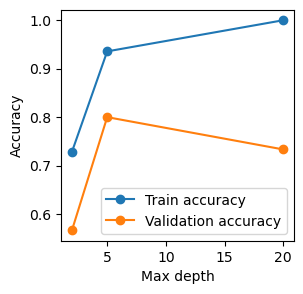

In [47]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(depths, train_accs, marker="o", label="Train accuracy")
ax.plot(depths, val_accs, marker="o", label="Validation accuracy")
ax.set_xlabel("Max depth")
ax.set_ylabel("Accuracy")
ax.legend()

What we see here:
- train accuracy increases with depth 
- validation accuracy peaks then drops: overfitting at large depths!!

We. can implement the same simple tree with scikit-learn:

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 5, 20]
train_accs_sklearn = []
val_accs_sklearn = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)

    train_accs_sklearn.append(accuracy_score(y_train, y_train_pred))
    val_accs_sklearn.append(accuracy_score(y_val, y_val_pred))

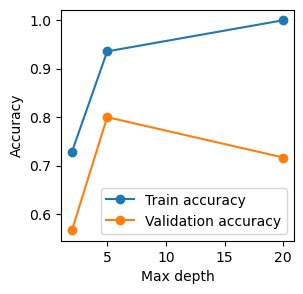

In [54]:
f, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(depths, train_accs_sklearn, marker="o", label="Train accuracy")
ax.plot(depths, val_accs_sklearn, marker="o", label="Validation accuracy")
ax.set_xlabel("Max depth")
ax.set_ylabel("Accuracy")
ax.legend()

We can visualize the tree with the best depth = 5: 

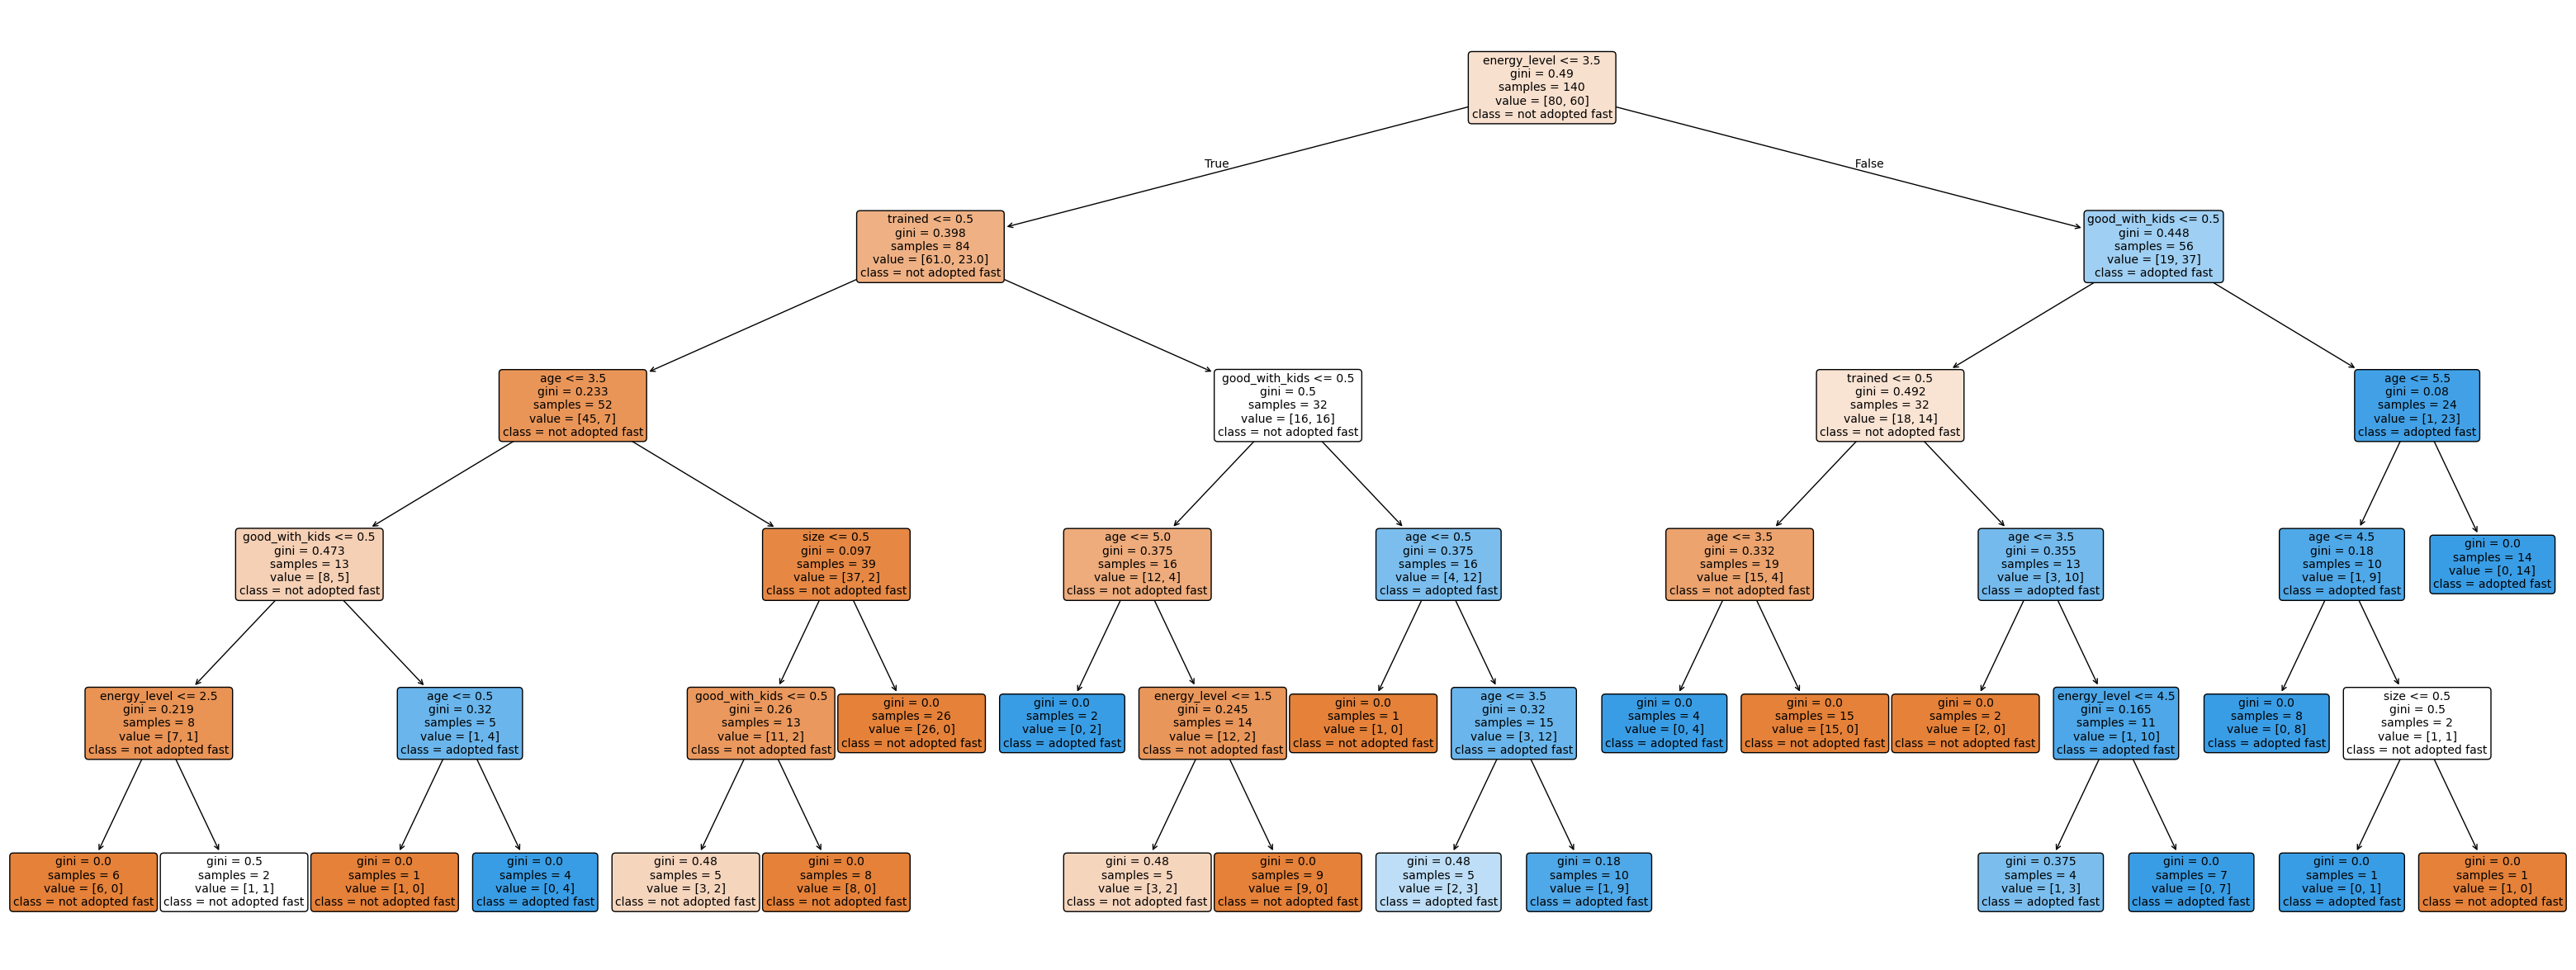

In [68]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(40, 15))
plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=["not adopted fast", "adopted fast"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Let's work a bit more on pruning:

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_accs_alpha = []
val_accs_alpha = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)

    train_accs_alpha.append(accuracy_score(y_train, y_train_pred))
    val_accs_alpha.append(accuracy_score(y_val, y_val_pred))

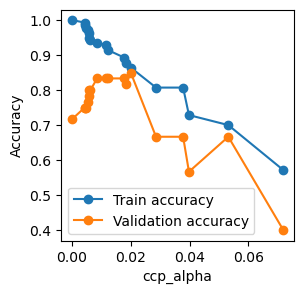

In [71]:
f, ax = plt.subplots(1,1,figsize=(3,3))
ax.plot(ccp_alphas, train_accs_alpha, marker="o", label="Train accuracy")
ax.plot(ccp_alphas, val_accs_alpha, marker="o", label="Validation accuracy")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("Accuracy")
ax.legend()
plt.show()

What we see: as cco_alpha increases
- tree becomes simpler
- train accuracy decreases
- validation accuracy improves first and then decreases (overpruned)

so: 
- no pruning -> overfit
- moderate pruing -> best validation accuracy
- too much pruning -> underfit